In [308]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error, mean_squared_error, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


In [309]:
df = pd.read_csv('MentalHealthImpactOnStudentDeuToSocialMedia.csv')
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [310]:
df_work = df.copy()
df_work

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [311]:
df_work.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [312]:
df_work.shape

(5000, 13)

In [313]:
df_work.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


In [314]:
df_work.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [315]:
df_work.duplicated().sum()

np.int64(2)

In [316]:
df_work[df_work.duplicated()]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


In [317]:
df_work.drop_duplicates(inplace=True)

In [318]:
df_work.duplicated().sum()


np.int64(0)

In [319]:
df_work.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [320]:
df_work.corr(numeric_only=True)['Mental_Health_Score']

Age                        0.100464
Avg_Daily_Usage_Hours     -0.816485
Daily_Unlocks             -0.790830
Study_Hours                0.752483
Physical_Activity_Hours    0.521591
Sleep_Hours_Per_Night      0.766462
Mental_Health_Score        1.000000
Name: Mental_Health_Score, dtype: float64

In [321]:
df_work.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

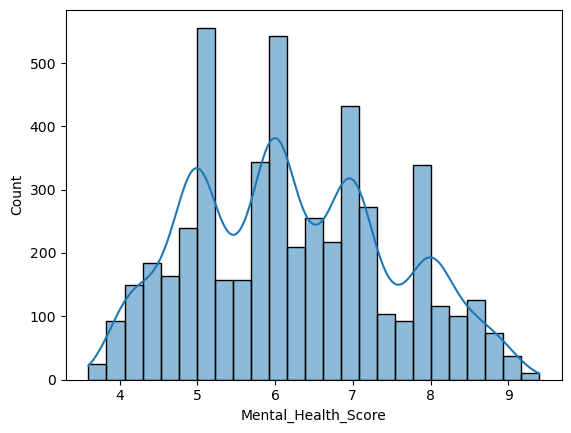

In [322]:
sns.histplot(df_work['Mental_Health_Score'], kde='Count')

<Axes: >

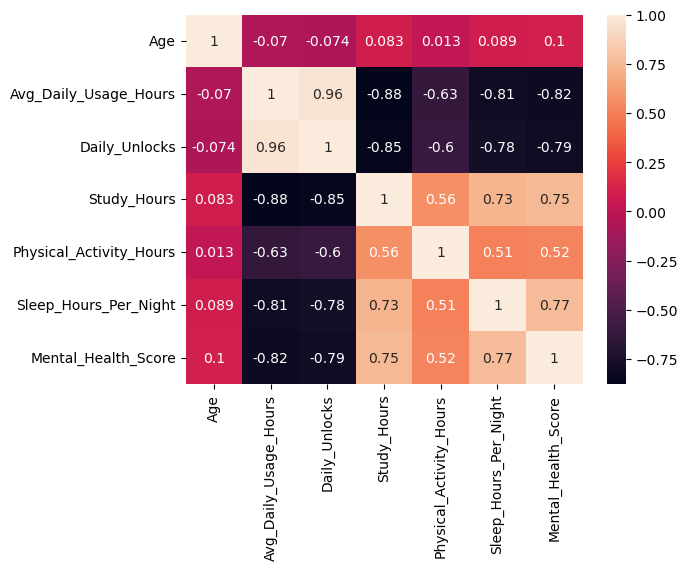

In [323]:
sns.heatmap(df_work.corr(numeric_only=True), annot=True)

In [324]:
df['Stress_Level'].unique()


<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

# Stress Level Vs Mental Health Score

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

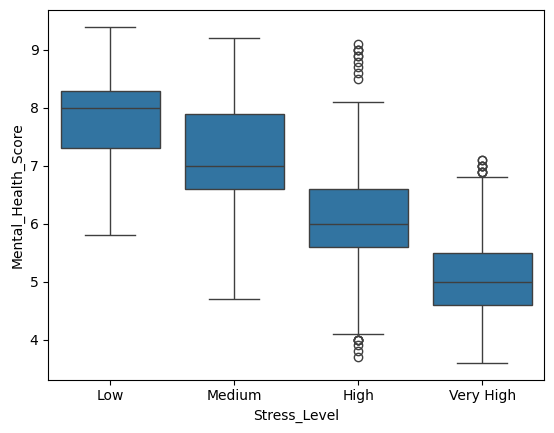

In [325]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score',data=df_work, order=order)

# Daily Usage Hours vs Mental Health Score

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

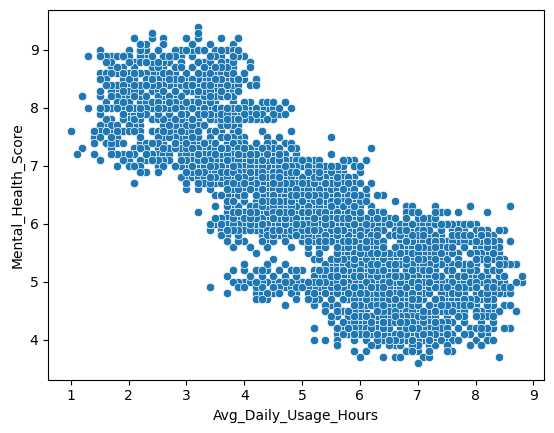

In [326]:
sns.scatterplot(
    data=df_work,
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score'
)


# Most Used Platform (Count)

In [327]:
df_work['Most_Used_Platform'].value_counts()


Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Instagram'),
  Text(1, 0, 'TikTok'),
  Text(2, 0, 'Facebook'),
  Text(3, 0, 'LinkedIn'),
  Text(4, 0, 'YouTube'),
  Text(5, 0, 'Twitter'),
  Text(6, 0, 'Snapchat'),
  Text(7, 0, 'WhatsApp'),
  Text(8, 0, 'LINE'),
  Text(9, 0, 'VKontakte'),
  Text(10, 0, 'KakaoTalk'),
  Text(11, 0, 'WeChat')])

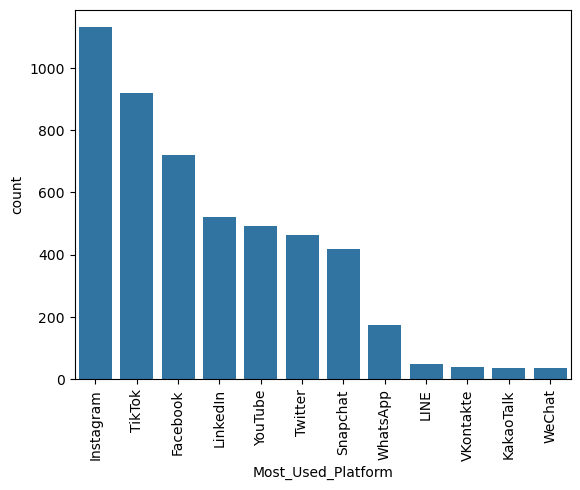

In [328]:
sns.countplot(x=df_work['Most_Used_Platform'], order=df_work['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation=90)


# Checking Outliers

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Age'),
  Text(1, 0, 'Avg_Daily_Usage_Hours'),
  Text(2, 0, 'Daily_Unlocks'),
  Text(3, 0, 'Study_Hours'),
  Text(4, 0, 'Physical_Activity_Hours'),
  Text(5, 0, 'Sleep_Hours_Per_Night'),
  Text(6, 0, 'Mental_Health_Score')])

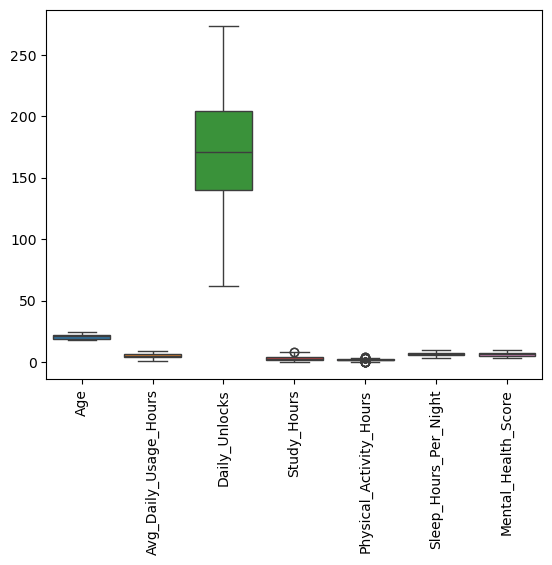

In [329]:
sns.boxplot(data=df_work[['Age',
                     'Avg_Daily_Usage_Hours',
                     'Daily_Unlocks',
                     'Study_Hours',
                     'Physical_Activity_Hours',
                     'Sleep_Hours_Per_Night',
                     'Stress_Level',
                     'Mental_Health_Score']])

plt.xticks(rotation=90)

In [330]:
# Select only numerical columns 
num_features = df_work.select_dtypes(include='number')

# Calcuate Q1 and Q3
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)

#Calculate IQR
IQR = Q3 - Q1

#Calcuate lower and upper bounds 
lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR

#Find outliner 
outliers = (num_features < lower_bound) | (num_features> upper_bound)

#Count outliers in each columns 
print("Number of outliers in each column: ")
print(outliers.sum())

Number of outliers in each column: 
Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [331]:
study_outliers = df_work[
    (df_work['Study_Hours'] < lower_bound['Study_Hours']) |
    (df_work['Study_Hours'] > upper_bound['Study_Hours'])
]

study_outliers

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
2948,23,Female,Other,Graduate,LinkedIn,Education,1.8,107,8.3,2.5,8.0,Low,7.4
4589,23,Female,Other,Graduate,LinkedIn,Education,1.7,107,8.3,2.5,7.9,Low,7.5


In [332]:
physical_outliers = df_work[
    (df_work['Physical_Activity_Hours'] < lower_bound['Physical_Activity_Hours']) |
    (df_work['Physical_Activity_Hours'] > upper_bound['Physical_Activity_Hours'])
]

physical_outliers

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
934,22,Female,Other,Undergraduate,TikTok,Entertainment,2.3,93,5.8,3.6,8.0,Low,8.5
1784,22,Male,Afghanistan,Undergraduate,LinkedIn,Education,2.9,132,4.2,3.6,7.0,Medium,7.0
2082,21,Male,India,Undergraduate,Instagram,Entertainment,3.3,136,5.9,3.6,6.9,Medium,7.2
2277,20,Male,Other,Undergraduate,Facebook,Networking,6.8,222,2.6,-0.1,4.7,Very High,4.6
2512,24,Female,Other,Graduate,Instagram,Entertainment,2.1,103,7.2,3.6,8.1,Low,8.7
2549,22,Male,Afghanistan,Undergraduate,LinkedIn,Education,2.6,132,4.2,3.6,6.8,Medium,7.1
2923,23,Female,USA,Graduate,Snapchat,Entertainment,7.9,223,1.1,-0.1,5.8,Very High,5.2
3051,22,Male,Japan,Undergraduate,Twitter,News,4.6,149,3.1,3.7,7.4,Medium,8.0
3056,19,Male,Other,Undergraduate,LinkedIn,Education,7.8,252,1.6,-0.3,5.7,Very High,4.3
3422,24,Male,Other,Graduate,Twitter,News,8.2,245,0.7,-0.1,5.8,Very High,4.4


In [333]:
(df_work['Physical_Activity_Hours'] < 0).sum()

np.int64(10)

In [334]:
df_work.loc[df_work['Physical_Activity_Hours'] < 0, 'Physical_Activity_Hours'] = np.nan

In [335]:
(df_work['Physical_Activity_Hours'] < 0).sum()

np.int64(0)

In [336]:
df_work['Physical_Activity_Hours'] = df_work['Physical_Activity_Hours'].fillna(df_work['Physical_Activity_Hours'].mean())

In [337]:
df_work.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

In [338]:
categorical_value = ['Country','Academic_Level','Purpose_Of_Use']

lst_cat = []

for cat in categorical_value:
    values = df_work[cat].value_counts()
    lst_cat.append({cat: values})

In [339]:
lst_cat

[{'Country': Country
  Other         1879
  India          389
  USA            354
  Canada         230
  Australia      198
                ... 
  Montenegro       1
  Bosnia           1
  Kuwait           1
  Yemen            1
  Syria            1
  Name: count, Length: 111, dtype: int64},
 {'Academic_Level': Academic_Level
  Undergraduate    3630
  Graduate          918
  High School       450
  Name: count, dtype: int64},
 {'Purpose_Of_Use': Purpose_Of_Use
  Entertainment    2551
  Education        1093
  Networking        793
  News              561
  Name: count, dtype: int64}]

In [340]:
country_counts = df_work['Country'].value_counts()

In [341]:
top_10_countries = country_counts.head(10).index

df_work['Country'] = df_work['Country'].where(
    df_work['Country'].isin(top_10_countries),
    'Others'
)

In [342]:
df_work['Country'].value_counts()

Country
Other        1879
Others       1352
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [343]:
df_work.info()

<class 'pandas.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   str    
 2   Country                  4998 non-null   str    
 3   Academic_Level           4998 non-null   str    
 4   Most_Used_Platform       4998 non-null   str    
 5   Purpose_Of_Use           4998 non-null   str    
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   str    
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 776.5 KB


In [344]:
X = df_work.drop('Mental_Health_Score', axis=1)
y = df_work['Mental_Health_Score']

In [345]:
df_work

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [346]:
df_work.info()

<class 'pandas.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   str    
 2   Country                  4998 non-null   str    
 3   Academic_Level           4998 non-null   str    
 4   Most_Used_Platform       4998 non-null   str    
 5   Purpose_Of_Use           4998 non-null   str    
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   str    
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 776.5 KB


# Train Test Split

In [368]:
numeric_features = [
    'Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
    'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night'
]

categorical_features = [
    'Gender', 'Country', 'Academic_Level',
    'Most_Used_Platform', 'Purpose_Of_Use'
]

In [369]:
X = df_work.drop('Mental_Health_Score', axis=1)
y = df_work['Mental_Health_Score']

In [370]:
X

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium


In [371]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

In [372]:
# Preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])



In [373]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('linear', LinearRegression())
])

In [374]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

In [375]:
lr_pred = lr_pipeline.predict(X_test)
lr_pred

array([4.4351873 , 5.39757704, 5.04780272, ..., 5.10810247, 6.85774138,
       7.24164334], shape=(3999,))

In [376]:
lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.7301975567959007
Accuracy of Testing 0.7266192205768229
MAE 0.5344192519277191


# Random Forest

In [377]:
rf_pipeline = Pipeline([
    ('preprocesser', preprocessor),
    ('random_forest', RandomForestRegressor(random_state=42))
])

In [378]:
rf_pipeline.fit(X_train, y_train)
rf_preds          = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")

Accuracy of Training 0.9729732328432359
Accuracy of Testing 0.8164266847029736
MAE : 0.4240980245061265


# Random Forest with Hyperparameter tuning

In [380]:
# #Without pipeline
# from scipy.stats import randint
# param_dist = {
#     'n_estimators': randint(100, 500),
#     'max_depth': [5, 10, 15, 20, None],
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 10),
#     'max_features': ['sqrt', 'log2', None]
# }

# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=42),
#     param_distributions=param_dist,
#     n_iter=50,                 # number of random combinations to try
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     random_state=42,
#     verbose=2
# )

# random_search.fit(X_train, y_train)

# print("Best Parameters:", random_search.best_params_)
# print("Best CV Score:", random_search.best_score_)s

In [386]:

# Hyperparameter search space
param_grid = {
    'random_forest__n_estimators': [100, 200, 300],
    'random_forest__max_depth': [5, 10, 20, None],
    'random_forest__min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)
print("Test R²:", random_search.score(X_test, y_test))

Best Parameters: {'random_forest__n_estimators': 100, 'random_forest__min_samples_split': 5, 'random_forest__max_depth': None}
Best CV R²: 0.792729429132005
Test R²: 0.8135323700210737


# Model Evaluation

In [387]:

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.726619     0.730198  0.534419  0.670173
1  Random Forest (default)  0.816427     0.972973  0.424098  0.549172
2    Random Forest (tuned)  0.813532     0.960012  0.427901  0.553484


# Model Save

In [388]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

In [389]:
joblib.dump(X.columns.to_list(), 'columns.pkl')

['columns.pkl']